In [1]:
import contextily as cx
import geopandas
import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas
from libpysal.cg.alpha_shapes import alpha_shape_auto
from shapely import Polygon

from esda.adbscan import ADBSCAN, get_cluster_boundary, remap_lbls

In [2]:
tab = pandas.read_csv("data/berlin-listings.csv")
tab.head(2)

,Unnamed: 0,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,0,17260587,https://www.airbnb.com/rooms/17260587,20170507222235,2017-05-08,Kunterbuntes Zimmer mit eigenem Bad für jedermann,"Meine Unterkunft ist gut für paare, alleinreis...",NaN,"Meine Unterkunft ist gut für paare, alleinreis...",none,...,10.0,f,NaN,NaN,t,flexible,f,f,3,2.00
1,1,17227881,https://www.airbnb.com/rooms/17227881,20170507222235,2017-05-08,Modernes Zimmer in Berlin Pankow,Es ist ein schönes gepflegtes und modernes Zim...,Das Haus befindet sich direkt vor eine Tram Ha...,Es ist ein schönes gepflegtes und modernes Zim...,none,...,10.0,f,NaN,NaN,t,flexible,f,f,1,1.29


In [3]:
tab.shape

(20053, 96)

In [4]:
tab = tab.sample(n=2000, random_state=1234)

In [5]:
db_ll = geopandas.GeoDataFrame(
    tab,
    geometry=geopandas.points_from_xy(tab.longitude, tab.latitude),
    crs=4326,
)

In [6]:
db = db_ll.to_crs(epsg=5243)

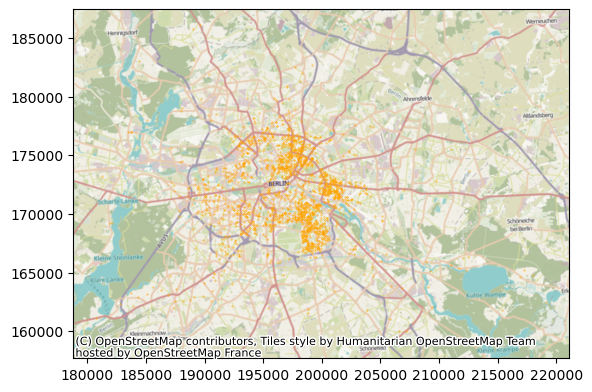

In [7]:
ax = db.plot(markersize=0.1, color="orange")
cx.add_basemap(ax, crs=db.crs.to_string());

In [8]:
db["X"] = db.geometry.x
db["Y"] = db.geometry.y

In [9]:
db.shape[0] * 0.01

20.0

In [10]:
%%time
# Get clusters
adbs = ADBSCAN(500, 20, pct_exact=0.5, reps=10, keep_solus=True)
np.random.seed(1234)
adbs.fit(db)

CPU times: user 394 ms, sys: 995 μs, total: 395 ms
Wall time: 395 ms


,eps,500
,min_samples,20
,algorithm,'auto'
,n_jobs,1
,pct_exact,0.5
,reps,10
,keep_solus,True
,pct_thr,0.9


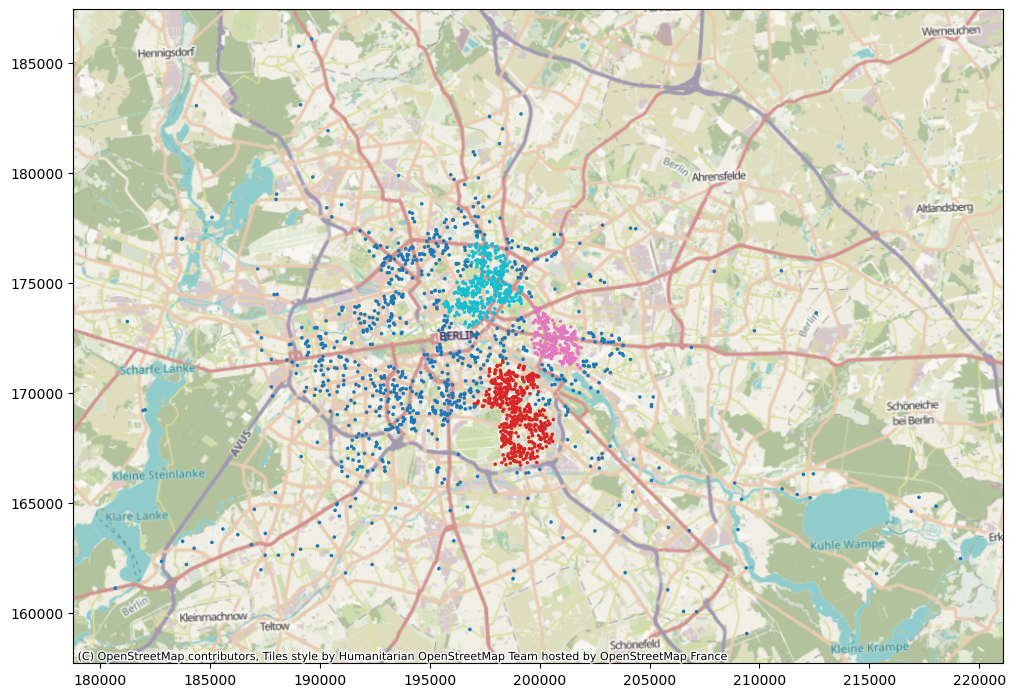

In [11]:
ax = db.assign(lbls=adbs.votes["lbls"]).plot(
    column="lbls", categorical=True, markersize=2.5, figsize=(12, 12)
)
cx.add_basemap(ax, crs=db.crs.to_string());

In [12]:
%%time
polys = get_cluster_boundary(adbs.votes["lbls"], db, crs=db.crs)

CPU times: user 6.93 s, sys: 436 ms, total: 7.37 s
Wall time: 7.37 s


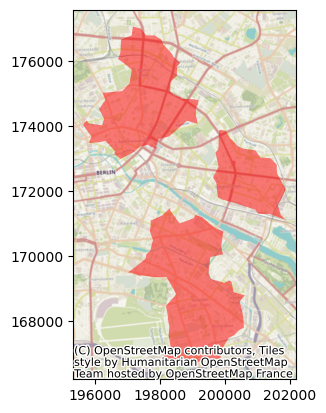

In [13]:
ax = polys.plot(alpha=0.5, color="red")
cx.add_basemap(ax, crs=polys.crs.to_string());

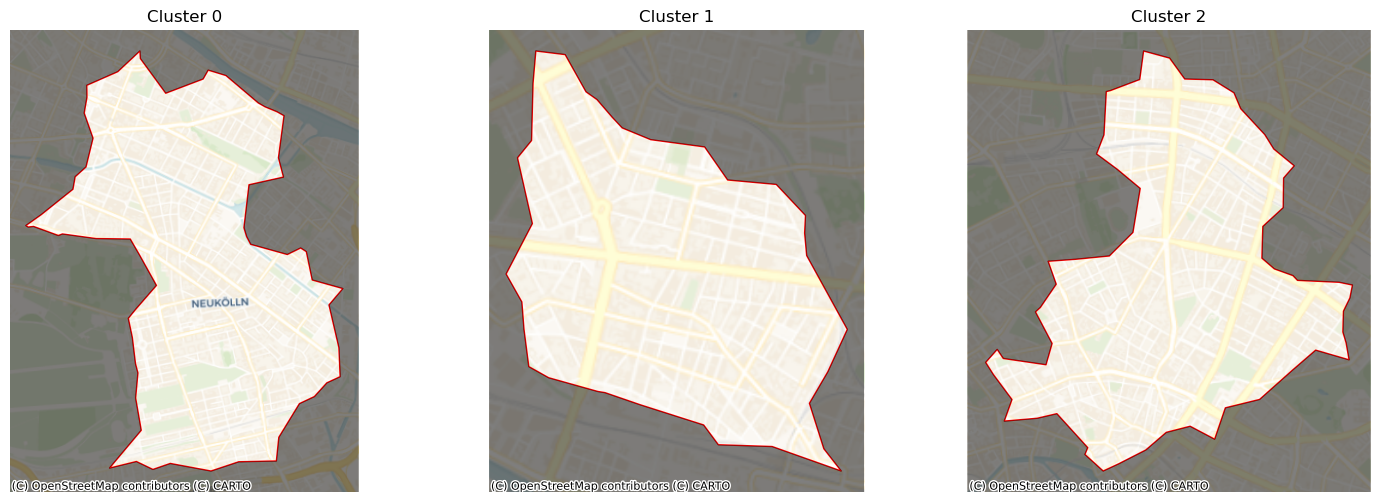

In [14]:
f, axs = plt.subplots(1, 3, figsize=(18, 6))
for i, ax in enumerate(axs):
    # Plot the boundary of the cluster found
    ax = polys.iloc[[i]].plot(ax=ax, edgecolor="red", facecolor="none")
    # Add basemap
    cx.add_basemap(
        ax, crs=polys.crs.to_string(), source=cx.providers.CartoDB.Voyager, zoom=13
    )
    # Extra to dim non-cluster areas
    (minx, maxx), (miny, maxy) = ax.get_xlim(), ax.get_ylim()
    bb = Polygon([(minx, miny), (maxx, miny), (maxx, maxy), (minx, maxy), (minx, miny)])
    geopandas.GeoSeries([bb.difference(polys.iloc[i])], crs=polys.crs).plot(
        ax=ax, color="k", alpha=0.5
    )
    ax.set_axis_off()
    ax.set_title(f"Cluster {polys.iloc[[i]].index[0]}")
plt.show()

In [15]:
# %%time
solus_rl = remap_lbls(adbs.solus, db, n_jobs=-1)
lines = []
for rep in solus_rl:
    line = get_cluster_boundary(solus_rl[rep], db, crs=db.crs, n_jobs=-1)
    line = line.boundary
    line = (
        line.reset_index()
        .rename(columns={0: "geometry", "index": "cluster_id"})
        .assign(rep=rep)
    )
    lines.append(line)
lines = pandas.concat(lines)
lines = geopandas.GeoDataFrame(lines, geometry=lines["geometry"], crs=db.crs)
lines

,cluster_id,geometry,rep
0,0,"LINESTRING (200621.527 168784.817, 200463.72 1...",rep-00
1,1,"LINESTRING (202254.25 171209.23, 202196.004 17...",rep-00
2,2,"LINESTRING (197037.991 172632.547, 196828.409 ...",rep-00
3,3,"LINESTRING (194118.515 169319.718, 193986.09 1...",rep-00
4,4,"LINESTRING (196753.952 171244.854, 196482.217 ...",rep-00
...,...,...,...
2,2,"LINESTRING (196610.634 176487.827, 196591.6 17...",rep-09
3,4,"LINESTRING (195517.485 168999.87, 195258.086 1...",rep-09
4,5,"LINESTRING (194609.924 176051.122, 194202.994 ...",rep-09
5,6,"LINESTRING (193340.736 174061.951, 193257.01 1...",rep-09


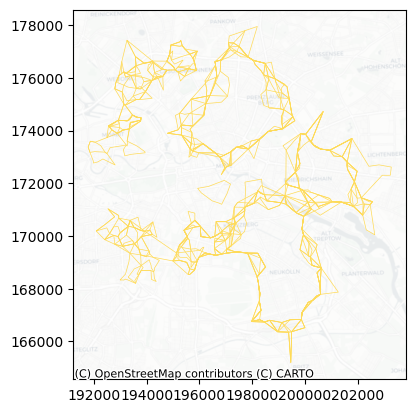

In [16]:
ax = lines.plot(color="#FFDB58", linewidth=0.5)
cx.add_basemap(
    ax, alpha=0.5, source=cx.providers.CartoDB.Positron, crs=lines.crs.to_string()
)

<Axes: >

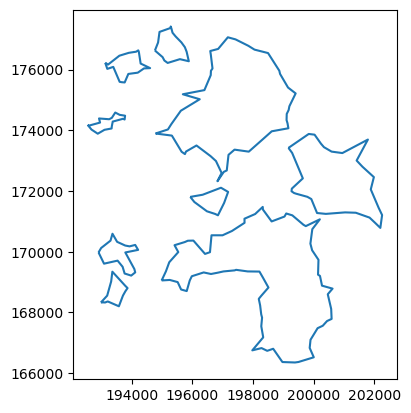

In [17]:
lines.query("rep == 'rep-00'").plot()

<Axes: >

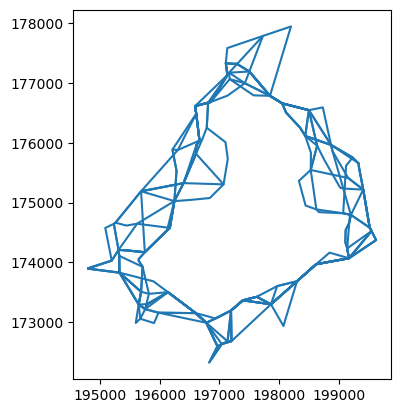

In [18]:
lines.query("cluster_id == '2'").plot()

In [19]:
from ipywidgets import IntSlider, interact

In [20]:
def plot_rep(rep):
    f, ax = plt.subplots(1, figsize=(9, 9))
    ax.set_facecolor("k")
    # Background points
    db[["X", "Y"]].plot.scatter("X", "Y", ax=ax, color="0.25", s=0.5)
    # Boundaries
    cs = lines.query(f"rep == 'rep-{str(rep).zfill(2)}'")
    cs.plot(ax=ax, color="red")
    # Cluster IDs
    for s, row in cs.iterrows():
        ax.text(row.geometry.centroid.x, row.geometry.centroid.y, s, size=20, c="w")
    return None


reps = range(len(lines["rep"].unique()))
slider = IntSlider(min=min(reps), max=max(reps), step=1)
interact(plot_rep, rep=slider);

interactive(children=(IntSlider(value=0, description='rep', max=9), Output()), _dom_classes=('widget-interact'…

In [21]:
def plot_cluster(cluster_id):
    f, ax = plt.subplots(1, figsize=(9, 9))
    ax.set_facecolor("k")
    # Background points
    db[["X", "Y"]].plot.scatter("X", "Y", ax=ax, color="0.25", s=0.5, alpha=0.5)
    # Boundaries
    lines.query(f"cluster_id == '{cluster_id}'").plot(ax=ax, linewidth=1, alpha=0.5)
    return None


interact(plot_cluster, cluster_id=lines["cluster_id"].unique());

interactive(children=(Dropdown(description='cluster_id', options=('0', '1', '2', '3', '4', '5', '6', '7', '8')…